In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier

from agg import build_all_channel_aggregates, compute_liquidity_signals
from notebook_shared import SharedNotebook
# from notebook_shared_lgbm_early_stopping import SharedNotebook


In [8]:
shd = SharedNotebook(algorithm=LGBMClassifier())
def wrangle(is_train: bool=True):
    df_to_use = pd.DataFrame()
    if is_train:
        shd.read_dataset("Train.csv", is_train=is_train)
        df_to_use = shd.train_df if shd.train_df is not None else pd.DataFrame()
    else:
        shd.read_dataset("Test.csv", is_train=is_train)
        df_to_use = shd.test_df if shd.test_df is not None else pd.DataFrame()

    # Month over month calculations
    running_df = shd.calculate_monthovermonth(["total_value", "highest_amount"])

    # Avg mom calculations (normally calculated inside the notebook)
    # print("Avg mom calculations....")
    # if df_to_use is not None:
    #     av_mom_df = shd.feature_pipeline.bal_avg_mom_calculations(df_to_use)
    # else:
    #     raise ValueError("dataframe to use is None")

    # running_df = pd.concat([running_df, av_mom_df], axis=1)

    # Removing autocorrelation features
    print("Removing autocorrelation features....")
    shd.remove_correlated_features(running_df)


    # Joining with the existing original dataset
    print("Aggregation, Liquidity signals andJoining with the existing original dataset....")
    train_df = pd.concat([df_to_use, running_df], axis=1)
    out = build_all_channel_aggregates(df_to_use)
    sig = compute_liquidity_signals(df_to_use, out)
    train_df = pd.concat([train_df, sig], axis=1)

    # If there is any numpy infite number raise exception
    if train_df.isin([np.inf, -np.inf]).any().sum():
        raise ValueError("There is any numpy infite number. Algorithm may fail to train.")

    # Remove features defined to be less useful
    print("Removing features defined to be less useful....")
    shd.define_features_to_remove(train_df)

    return train_df


In [9]:
running_df = wrangle()
running_df.head(2)


Is self.test available:  False
Is it training mode:  True
['m1_paybill_total_value', 'm2_paybill_total_value', 'm3_paybill_total_value', 'm4_paybill_total_value', 'm5_paybill_total_value', 'm6_paybill_total_value', 'm1_merchantpay_total_value', 'm2_merchantpay_total_value', 'm3_merchantpay_total_value', 'm4_merchantpay_total_value', 'm5_merchantpay_total_value', 'm6_merchantpay_total_value', 'm1_received_total_value', 'm2_received_total_value', 'm3_received_total_value', 'm4_received_total_value', 'm5_received_total_value', 'm6_received_total_value', 'm1_deposit_total_value', 'm2_deposit_total_value', 'm3_deposit_total_value', 'm4_deposit_total_value', 'm5_deposit_total_value', 'm6_deposit_total_value', 'm1_withdraw_total_value', 'm2_withdraw_total_value', 'm3_withdraw_total_value', 'm4_withdraw_total_value', 'm5_withdraw_total_value', 'm6_withdraw_total_value']
Is self.test available:  False
Is it training mode:  True
['m1_paybill_highest_amount', 'm2_paybill_highest_amount', 'm3_payb

,arpu,age,gender,region,smartphone,segment,earning_pattern,x_90_d_activity_rate,m1_paybill_total_value,m1_paybill_highest_amount,...,withdraw_share_of_outflow,paybill_share_of_outflow,total_outflow_value,total_inflow_value,outflow_to_inflow_ratio,outflow_channel_entropy,withdraw_active_months,paybill_active_months,withdraw_share_trend,paybill_share_trend
0,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,58372.55,5352.41,...,0.498137,0.325910,332489.28,590474.93,0.563088,1.106951,1,4,0.622915,-0.246824
1,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,0.00,0.00,...,0.732322,0.126699,884314.06,1286319.71,0.687476,0.838202,6,4,-0.205591,0.143456


In [10]:
from build import ModelPipeline
from sklearn.model_selection import train_test_split

def prepare_df(X, is_train=True):
    if not is_train:
        X_test, _ = shd.feature_pipeline.transform(X, is_train=is_train)
        X_test = X_test.loc[:, ~X_test.columns.duplicated()]
        shd.remove_features_definedby_algorithm_gain(X_test, None)
        # shd.remove_netflow_features(X_test, None)
        shd.find_and_remove_mom_features(X_test)
        return X_test
    else:
        raw_train, raw_val = train_test_split(
            X,
            test_size=0.2,
            stratify=X[shd.feature_pipeline.target_col],
            random_state=42,
        )

        X_train, y_train = shd.feature_pipeline.transform(raw_train)
        X_val, y_val = shd.feature_pipeline.transform(raw_val)
        X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

        if y_train is None:
            raise ValueError("y_train is None")
        
        pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

        # Get dulicated columns and remain with one of them
        X_train, X_val = X_train.loc[:, ~X_train.columns.duplicated()], X_val.loc[:, ~X_val.columns.duplicated()]
        shd.remove_features_definedby_algorithm_gain(X_train, X_val)
        # shd.remove_netflow_features(X_train, X_val)
        shd.find_and_remove_mom_features(X_train)
        shd.find_and_remove_mom_features(X_val)

        return X_train, y_train, X_val, y_val, pos_weight

In [11]:
X_train, y_train, X_val, y_val, pos_weight = prepare_df(running_df)
X_train.head(2)

,arpu,age,x_90_d_activity_rate,m1_paybill_total_value,m1_paybill_highest_amount,m2_paybill_total_value,m2_paybill_highest_amount,m3_paybill_total_value,m3_paybill_highest_amount,m4_paybill_total_value,...,avg_recent3_cashout,avg_old3_cashout,inflow_cv_3m,inflow_cv_6m,outflow_cv_3m,outflow_cv_6m,recent3_avg_balance,old3_avg_balance,bal_cv_3m,bal_cv_6m
16946,3187.16,38,0.4573,0.0,0.00,0.0,0.0,427.23,423.38,0.0,...,3364.713333,2847.010000,1.063671,0.948016,1.470833,0.810179,948.113333,1621.750000,0.269724,0.477365
39245,4769.99,45,0.5526,9075.4,7483.94,0.0,0.0,26574.00,1923.44,0.0,...,199246.806667,46991.803333,1.182415,1.180883,0.390105,0.499469,10304.526667,6598.206667,0.187522,0.304367


In [14]:
model = shd.tune_lgbm(X_train, y_train, pos_weight=2.3)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best Parameters: {'colsample_bytree': 0.5, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 4000, 'num_leaves': 15, 'objective': 'binary', 'reg_alpha': 10, 'reg_lambda': 20, 'scale_pos_weight': 2.3}
Best CV Score: 0.9051


In [15]:
train_preds, val_preds = shd.run_predictions(model, X_train, X_val, y_train, y_val)

Train ROC:  0.9683364583333334
Val ROC:  0.9012507352941177
Val Log Loss:  0.27116866711842663


Classification report: 
               precision    recall  f1-score   support

           0       0.90      0.99      0.94      6800
           1       0.81      0.35      0.49      1200

    accuracy                           0.89      8000
   macro avg       0.85      0.67      0.71      8000
weighted avg       0.88      0.89      0.87      8000



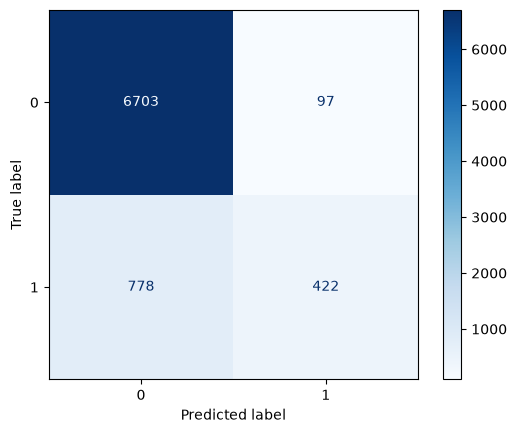

In [36]:
shd.build_cm(y_val, val_preds)

In [37]:
clb_model = shd.calibrate_model(model, X_train, y_train)
val_pred = shd.run_calibrated_predictions(clb_model, X_val)
val_pred

array([0.02363169, 0.05315829, 0.74840569, ..., 0.00580273, 0.00415061,
       0.13081174], shape=(8000,))

In [31]:
clb_model


,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LGBMClassifie... verbosity=-1)
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...x70af320e3ad0>, <sk

Classification report: 
               precision    recall  f1-score   support

           0       0.91      0.97      0.94      6800
           1       0.74      0.47      0.57      1200

    accuracy                           0.90      8000
   macro avg       0.82      0.72      0.76      8000
weighted avg       0.89      0.90      0.89      8000



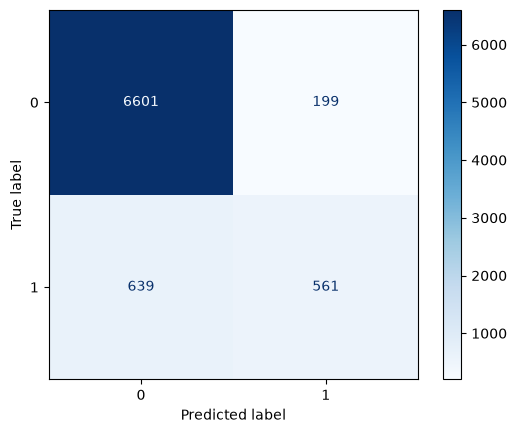

In [38]:
shd.build_cm(y_val, val_pred)

In [39]:
calibrated_pred = shd.display_val_prediction_stats(val_pred, y_val)

Val ROC:  0.9006734681372549
Val Log Loss:  0.25574488259033945


In [15]:
# Do the same process for test dataframe
shd = SharedNotebook(algorithm=LGBMClassifier(), is_train=False)
test_running_df = wrangle(is_train=False)
test_running_df.shape

Reaing test dataset
Is self.test available:  True
Is it training mode:  False
['m1_paybill_total_value', 'm2_paybill_total_value', 'm3_paybill_total_value', 'm4_paybill_total_value', 'm5_paybill_total_value', 'm6_paybill_total_value', 'm1_merchantpay_total_value', 'm2_merchantpay_total_value', 'm3_merchantpay_total_value', 'm4_merchantpay_total_value', 'm5_merchantpay_total_value', 'm6_merchantpay_total_value', 'm1_received_total_value', 'm2_received_total_value', 'm3_received_total_value', 'm4_received_total_value', 'm5_received_total_value', 'm6_received_total_value', 'm1_deposit_total_value', 'm2_deposit_total_value', 'm3_deposit_total_value', 'm4_deposit_total_value', 'm5_deposit_total_value', 'm6_deposit_total_value', 'm1_withdraw_total_value', 'm2_withdraw_total_value', 'm3_withdraw_total_value', 'm4_withdraw_total_value', 'm5_withdraw_total_value', 'm6_withdraw_total_value']
Is self.test available:  True
Is it training mode:  False
['m1_paybill_highest_amount', 'm2_paybill_highe

(30000, 182)

In [16]:
set(running_df.columns) - set(test_running_df.columns)

{'liquidity_stress_next_30d'}

In [17]:
X_test = prepare_df(test_running_df, is_train=False)
X_test.head(2)

,arpu,age,x_90_d_activity_rate,m1_paybill_total_value,m1_paybill_highest_amount,m2_paybill_total_value,m2_paybill_highest_amount,m3_paybill_total_value,m3_paybill_highest_amount,m4_paybill_total_value,...,avg_recent3_cashout,avg_old3_cashout,bal_cv_3m,bal_cv_6m,inflow_cv_3m,inflow_cv_6m,outflow_cv_3m,outflow_cv_6m,recent3_avg_balance,old3_avg_balance
0,2653.88,47,0.6905,0.00,0.00,0.0,0.0,21341.77,5938.05,7831.85,...,61776.256667,63108.470000,0.464655,0.315607,0.140551,0.887549,0.621571,0.776096,11300.963333,13561.640000
1,2653.88,47,0.6905,89420.67,4231.17,0.0,0.0,0.00,0.00,19568.77,...,207724.480000,147963.236667,0.505944,0.491602,0.686181,0.452080,0.569817,0.512618,7060.723333,6922.753333


In [18]:
set(X_train.columns) - set(X_test.columns)

set()

In [19]:
test_pred = shd.run_calibrated_predictions(model, X_test)

In [20]:
shd.save_submission_file(test_running_df, test_pred)

Submission file saved!


,ID,Target
0,ID_ED91AC7A28,0.045389
1,ID_29975A9C7E,0.060230
2,ID_F59CE25650,0.029137
3,ID_E875F68D1A,0.005619
4,ID_2902B1C0D0,0.015237
...,...,...
29995,ID_3C7CF79AEE,0.023365
29996,ID_F1651E73C4,0.013006
29997,ID_FD3F0934CA,0.253486
29998,ID_DA6916D6C7,0.014213


In [71]:
# Save current best model, both calibrated and uncalibrated
shd.save_model(model, "lgbm_model")
shd.save_model(clb_model, "lgbm_calibrated_model")